# Chapter 5: LLM-Based Tabular Data Generation (GReaT Framework)

**Chapter 5: Synthetic Data Generation**
**Section Reference**: Section 5.6 (LLMs for Structured Financial Data)

**Docker image**: `ml4t-gpu`

> **GPU recommended**: This notebook trains models with PyTorch/CUDA. It will run on CPU
> but training may be very slow. For GPU acceleration:
> ```bash
> docker compose run --rm ml4t-gpu python 05_synthetic_data/06_llm_tabular_great.py
> ```


## Purpose

This notebook implements **GReaT (Generate Realistic Tabular Data)** using the
actual `be-great` library to generate synthetic financial tabular data with LLMs.

## Learning Objectives

By completing this notebook, you will:
- Understand the serialization insight for applying LLMs to tabular data
- Fine-tune GPT-2 on serialized financial records using the GReaT framework
- Generate synthetic tabular data and evaluate fidelity
- Compare LLM-based generation to traditional methods (GANs, VAEs)

## Cross-References

- **Book**: Section 5.6 discusses GReaT and LLM-based tabular generation
- **Related**: [`02_tailgan_tail_risk`](02_tailgan_tail_risk.ipynb) (GAN for time series comparison)

---

## Key Concepts

1. **Serialization**: Convert table rows to natural language sentences
2. **Fine-tuning**: Train GPT-2 on serialized financial data
3. **Generation**: LLM produces new "sentences" parsed back to table rows
4. **Mixed Types**: Handle categorical, numerical, and text features naturally

## Why LLMs for Tabular Data?

- Captures complex feature dependencies through attention
- No explicit distribution assumptions
- Handles mixed data types naturally
- Pre-trained language understanding helps with feature names

## Prerequisites

- `be-great` library (`uv add be-great`) for the GReaT framework
- `transformers` library (installed as a `be-great` dependency)
- ETF data via `load_etfs()` from Ch2

## References

- Borisov et al. (2023). "Language Models are Realistic Tabular Data Generators"
- https://github.com/kathrinse/be_great

In [1]:
"""LLM-Based Tabular Data Generation — GReaT framework for synthetic financial data."""

# Note: temporal split used instead of train_test_split for financial data
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
from be_great import GReaT
from plotly.subplots import make_subplots
from scipy import stats
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

from data import load_etfs
from utils.paths import get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, plot_fidelity_comparison

# Suppress transformers warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="transformers")

/opt/ml4t/lib/python3.14/site-packages/multiprocess/connection.py:335: SyntaxWarning: 'return' in a 'finally' block
  return f
/opt/ml4t/lib/python3.14/site-packages/multiprocess/connection.py:337: SyntaxWarning: 'return' in a 'finally' block
  return self._get_more_data(ov, maxsize)


In [2]:
# GReaT framework parameters (Borisov et al. 2023)
N_SAMPLES = 2000  # Training samples from ETF data
N_GENERATE = 500  # Synthetic samples to generate
EPOCHS = 50  # Fine-tuning epochs
BATCH_SIZE = 16  # Training batch size
SEED = 42

In [3]:
set_global_seeds(SEED)

In [4]:
# Configuration
CONFIG = {
    "symbols": None,  # Load all ETFs
    "start_date": "2015-01-01",
    "n_samples": N_SAMPLES,
    "n_generate": N_GENERATE,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
}

# Checkpoint configuration
RETRAIN = False  # Set True to retrain even if checkpoint exists
CHECKPOINT_DIR = get_output_dir(5, "great") / "checkpoints" / "great_model"

## 1. Load Real ETF Data

We use actual ETF data to create a tabular dataset suitable for GReaT.
The function below engineers a mix of numerical features (returns, volatility)
and categorical features (direction, momentum regime) to showcase GReaT's
ability to handle mixed-type tabular data.

### Build Tabular Feature Set

Each row represents a single observation: lookback features (returns, volatility,
volume ratio) plus a forward-return target. Categorical columns encode direction,
momentum strength, and volatility regime -- feature types that GANs struggle with
but LLMs handle naturally via serialization.

In [5]:
def load_etf_tabular_data(
    symbols: list[str] | None, start_date: str, n_samples: int
) -> pd.DataFrame:
    """
    Load ETF data and create tabular features for GReaT.

    Creates features that mix numerical (returns, volatility) and
    categorical (direction, regime) for realistic tabular generation.
    """
    df = load_etfs()

    # Determine date column and filter by start date
    date_col = "timestamp" if "timestamp" in df.columns else "date"
    start_dt = datetime.strptime(start_date, "%Y-%m-%d")

    # Cast to date for consistent comparison across schemas
    df = df.filter(pl.col(date_col).cast(pl.Date) >= start_dt.date())

    if symbols:
        df = df.filter(pl.col("symbol").is_in(symbols))

    df = df.sort(["symbol", date_col])

    # Create tabular features per observation
    records = []

    for symbol in df["symbol"].unique().to_list():
        symbol_df = df.filter(pl.col("symbol") == symbol).sort(date_col)

        if len(symbol_df) < 30:
            continue

        close = symbol_df["close"].to_numpy()
        volume = symbol_df["volume"].to_numpy()
        dates = symbol_df[date_col].to_list()

        for i in range(20, len(close) - 5):
            # Lookback features
            ret_1d = (close[i] - close[i - 1]) / close[i - 1]
            ret_5d = (close[i] - close[i - 5]) / close[i - 5]
            ret_20d = (close[i] - close[i - 20]) / close[i - 20]
            # Volatility: std of daily returns over 20-day window
            window = close[i - 20 : i]
            daily_rets = window[1:] / window[:-1] - 1.0
            vol_20d = daily_rets.std()
            vol_ratio = volume[i] / np.mean(volume[i - 20 : i])

            # Forward return (target)
            fwd_ret_5d = (close[i + 5] - close[i]) / close[i]

            # Categorical features
            direction = "up" if ret_1d > 0 else "down"
            momentum = (
                "strong" if abs(ret_20d) > 0.05 else "weak" if abs(ret_20d) > 0.02 else "flat"
            )
            vol_regime = "high" if vol_20d > 0.02 else "normal" if vol_20d > 0.01 else "low"

            # Forward return absolute value for extreme move classification
            abs_fwd_ret_5d = abs(fwd_ret_5d)

            records.append(
                {
                    "timestamp": dates[i],  # For temporal split
                    "symbol": symbol,
                    "ret_1d": round(ret_1d * 100, 2),  # Percentage
                    "ret_5d": round(ret_5d * 100, 2),
                    "ret_20d": round(ret_20d * 100, 2),
                    "volatility": round(vol_20d * 100, 2),
                    "volume_ratio": round(vol_ratio, 2),
                    "direction": direction,
                    "momentum": momentum,
                    "vol_regime": vol_regime,
                    "fwd_ret_5d": round(fwd_ret_5d * 100, 2),
                    "abs_fwd_ret_5d": round(abs_fwd_ret_5d * 100, 2),  # For extreme move
                    "target": None,  # Will be computed after all rows
                }
            )

    result_df = pd.DataFrame(records)

    # Sort by date for proper temporal split (critical for financial data)
    result_df = result_df.sort_values("timestamp").reset_index(drop=True)

    # Compute extreme move target: |fwd_ret| > 90th percentile
    # This exploits volatility clustering which has real predictive signal
    threshold = result_df["abs_fwd_ret_5d"].quantile(0.90)
    result_df["target"] = (result_df["abs_fwd_ret_5d"] > threshold).astype(int)

    # Truncate if too many (preserve temporal order)
    if len(result_df) > n_samples:
        result_df = result_df.head(n_samples)

    return result_df.reset_index(drop=True)

### Load and Inspect

Load the ETF feature table and verify the mix of numerical and categorical columns.

In [6]:
print("Loading real ETF data...")
df = load_etf_tabular_data(CONFIG["symbols"], CONFIG["start_date"], CONFIG["n_samples"])
print(f"Loaded {len(df)} samples with {len(df.columns)} features")
print(f"\nFeature types:\n{df.dtypes}")
print("\nSample rows:")
print(df.head())

Loading real ETF data...


Loaded 2000 samples with 13 features

Feature types:
timestamp          object
symbol             object
ret_1d            float64
ret_5d            float64
ret_20d           float64
volatility        float64
volume_ratio      float64
direction          object
momentum           object
vol_regime         object
fwd_ret_5d        float64
abs_fwd_ret_5d    float64
target              int64
dtype: object

Sample rows:
    timestamp symbol  ret_1d  ret_5d  ret_20d  volatility  volume_ratio  \
0  2015-02-02    DBC    1.38    2.38    -3.24        1.16          1.13   
1  2015-02-02    IVW    0.91   -2.00    -0.67        1.07          1.38   
2  2015-02-02    IEF   -0.13    1.30     3.64        0.48          6.85   
3  2015-02-02    DIA    1.06   -1.83    -2.54        1.08          1.19   
4  2015-02-02    XLV    0.56   -2.31     1.50        1.08          1.51   

  direction momentum vol_regime  fwd_ret_5d  abs_fwd_ret_5d  target  
0        up     weak     normal        3.17            3.17 

## 2. GReaT: LLM-Based Generation

Using the actual `be-great` library with distilgpt2 for fast training.

In [7]:
# Prepare training data (drop symbol and date to avoid memorization)
train_df = df.drop(columns=["symbol", "timestamp"])

# Check for existing checkpoint
checkpoint_exists = CHECKPOINT_DIR.exists() and (CHECKPOINT_DIR / "config.json").exists()

if checkpoint_exists and not RETRAIN:
    print(f"\nLoading GReaT model from checkpoint: {CHECKPOINT_DIR}")
    great = GReaT.load_from_dir(str(CHECKPOINT_DIR))
    print("Checkpoint loaded successfully!")
else:
    if RETRAIN and checkpoint_exists:
        print("\nRETRAIN=True, retraining despite existing checkpoint...")
    else:
        print("\nNo checkpoint found, training from scratch...")

    print("Initializing GReaT with distilgpt2...")

    # Use distilgpt2 (82M parameters) — smaller LLM keeps fine-tuning tractable
    # on CPU/single-GPU. Larger backbones (GPT-2 medium/large, LLaMA) trade
    # compute for fidelity but do not change the GReaT serialization pipeline.
    great = GReaT(
        llm="distilgpt2",
        batch_size=CONFIG["batch_size"],
        epochs=CONFIG["epochs"],
        experiment_dir=str(get_output_dir(5, "great") / "trainer_great"),
        save_steps=5000,  # Don't save intermediate checkpoints
        logging_steps=100,
    )

    print(f"Training on {len(train_df)} samples...")
    print(f"Epochs: {CONFIG['epochs']}, Batch size: {CONFIG['batch_size']}")

    # Train the model
    great.fit(train_df)

    # Save checkpoint
    CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
    great.save(str(CHECKPOINT_DIR))
    print(f"\nCheckpoint saved to: {CHECKPOINT_DIR}")

    print("\nTraining complete!")


Loading GReaT model from checkpoint: 05_synthetic_data/output/great/checkpoints/great_model


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Checkpoint loaded successfully!


## 3. Generate Synthetic Data

In [8]:
print(f"\nGenerating {CONFIG['n_generate']} synthetic samples...")

# Generate synthetic data — guided sampling enforces the column schema row by
# row and is essential when fine-tuning is short (the unguided sampler tends
# to drop columns on undertrained models). With well-trained checkpoints,
# guided_sampling=False is faster and produces equivalent quality.
synthetic_df = great.sample(
    n_samples=CONFIG["n_generate"],
    max_length=500,
    guided_sampling=True,
)

print(f"Generated {len(synthetic_df)} samples")
print("\nSample synthetic rows:")
print(synthetic_df.head())

# Check for parsing errors (NaN values)
nan_counts = synthetic_df.isna().sum()
if nan_counts.sum() > 0:
    print(f"\nParsing issues (NaN counts):\n{nan_counts[nan_counts > 0]}")


Generating 500 synthetic samples...


Generated 500 samples

Sample synthetic rows:
   ret_1d  ret_5d  ret_20d  volatility  volume_ratio direction momentum  \
0   -0.47    3.32    -4.41        1.43          0.68      down     weak   
1   -0.41   -0.87    -0.18        0.89          0.47      down     flat   
2   -0.02   -0.16    -0.31        0.15          0.73      down     flat   
3   -0.12   -0.24    -0.77        0.11          0.83      down     flat   
4   -0.37   -3.28    -1.04        0.69          0.53      down     flat   

  vol_regime  fwd_ret_5d  abs_fwd_ret_5d  target  
0     normal        0.73            0.73       0  
1        low       -0.41            0.41       0  
2        low       -2.08            2.08       0  
3        low        0.87            0.87       0  
4        low       -1.41            1.41       0  


**Observation**: The generated rows should contain plausible feature values -- returns
near zero with occasional larger moves, volatility in realistic ranges, and valid
categorical labels. NaN counts above zero indicate parsing failures where the LLM
produced text that could not be mapped back to the original schema. This is a known
limitation of autoregressive generation: the model can "hallucinate" tokens that
break column parsing, especially with short fine-tuning. Increasing epochs and using
larger base models (GPT-2 medium/large) reduces parsing errors significantly.

## 4. Fidelity: Visual Comparison with PCA and t-SNE

We project both real and synthetic data into 2D using only numerical features
to assess whether the generator covers the same regions of the data manifold.

utils/style.py:764: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


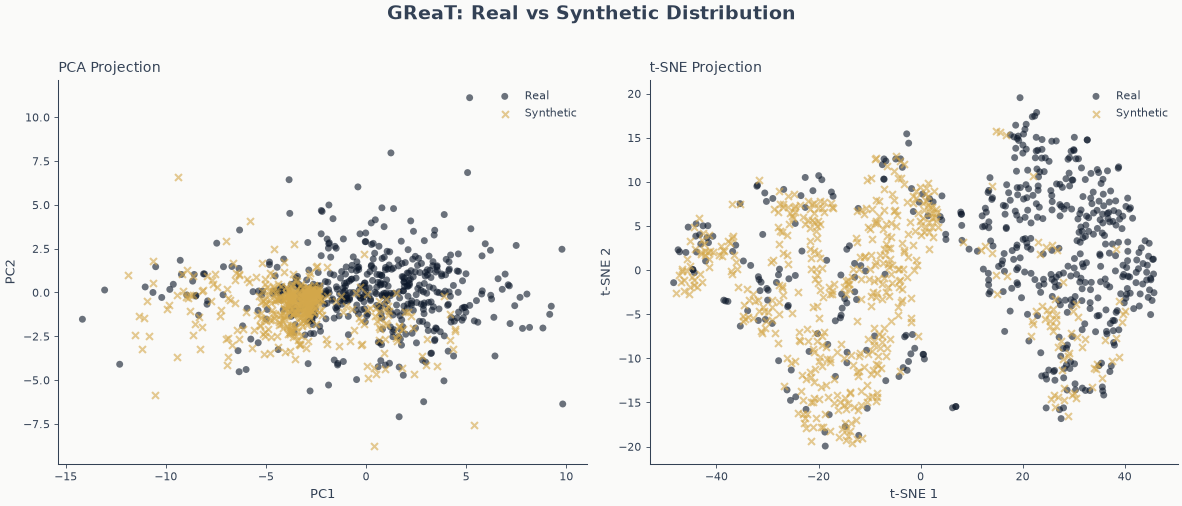

In [9]:
# Extract numerical columns for visualization
numerical_cols = ["ret_1d", "ret_5d", "ret_20d", "volatility", "volume_ratio", "fwd_ret_5d"]
available_cols = [c for c in numerical_cols if c in df.columns and c in synthetic_df.columns]

# Convert to numpy arrays (handling potential NaN from LLM parsing errors)
real_data = df[available_cols].dropna().values
synth_data = synthetic_df[available_cols].apply(pd.to_numeric, errors="coerce").dropna().values

if len(synth_data) >= 50:  # Need enough samples for meaningful visualization
    fig = plot_fidelity_comparison(
        real_data,
        synth_data,
        title="GReaT: Real vs Synthetic Distribution",
        n_samples=min(500, len(synth_data)),
    )
    plt.show()
else:
    print(f"Insufficient valid synthetic samples ({len(synth_data)}) for fidelity visualization")

**Interpretation**: Overlapping point clouds confirm that GReaT-generated tabular
data occupies similar regions of feature space as real data. LLM-based generation
can capture complex feature dependencies via autoregressive modeling. Gaps may
indicate parsing errors or LLM hallucination on certain feature combinations.

## 5. Compare Real vs Synthetic Distributions

In [10]:
compare_cols = [c for c in df.columns if c != "asset" and c in synthetic_df.columns]
numerical_cols = ["ret_1d", "ret_5d", "ret_20d", "volatility", "volume_ratio", "fwd_ret_5d"]
categorical_cols = ["direction", "momentum", "vol_regime"]

numerical_rows = []
for col in numerical_cols:
    if col in synthetic_df.columns:
        real_vals = df[col].dropna()
        synth_vals = pd.to_numeric(synthetic_df[col], errors="coerce").dropna()
        if len(synth_vals) > 0:
            numerical_rows.append(
                {
                    "feature": col,
                    "real_mean": real_vals.mean(),
                    "synth_mean": synth_vals.mean(),
                    "real_std": real_vals.std(),
                    "synth_std": synth_vals.std(),
                }
            )
numerical_comparison = pd.DataFrame(numerical_rows).set_index("feature").round(3)
numerical_comparison

,real_mean,synth_mean,real_std,synth_std
feature,,,,
ret_1d,0.172,-0.318,1.020,0.457
ret_5d,0.650,-0.726,1.994,1.032
ret_20d,2.311,-0.730,3.725,2.626
volatility,1.077,0.678,0.597,0.452
volume_ratio,0.905,0.804,1.204,0.390
fwd_ret_5d,0.131,-0.751,1.952,1.490


In [11]:
categorical_rows = []
for col in categorical_cols:
    if col in synthetic_df.columns:
        real_dist = df[col].value_counts(normalize=True)
        synth_dist = synthetic_df[col].value_counts(normalize=True)
        for cat in real_dist.index:
            categorical_rows.append(
                {
                    "feature": col,
                    "category": cat,
                    "real_pct": real_dist.get(cat, 0) * 100,
                    "synth_pct": synth_dist.get(cat, 0) * 100,
                }
            )
categorical_comparison = pd.DataFrame(categorical_rows).round(1)
categorical_comparison

,feature,category,real_pct,synth_pct
0,direction,up,54.9,5.2
1,direction,down,45.1,94.8
2,momentum,weak,36.4,21.0
3,momentum,flat,36.0,69.2
4,momentum,strong,27.6,9.8
5,vol_regime,low,48.4,69.0
6,vol_regime,normal,44.8,30.2
7,vol_regime,high,6.7,0.8


## 5. Visualize Distributions

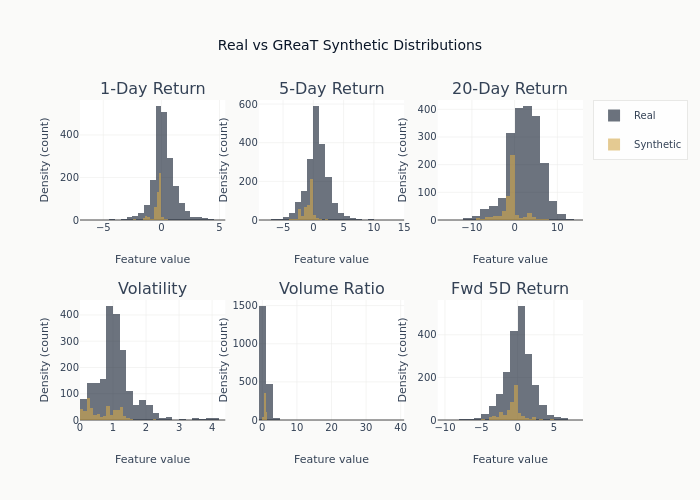

In [12]:
# Numerical distributions
fig = make_subplots(
    rows=2,
    cols=3,
    subplot_titles=[
        "1-Day Return",
        "5-Day Return",
        "20-Day Return",
        "Volatility",
        "Volume Ratio",
        "Fwd 5D Return",
    ],
)

plot_cols = ["ret_1d", "ret_5d", "ret_20d", "volatility", "volume_ratio", "fwd_ret_5d"]
positions = [(1, 1), (1, 2), (1, 3), (2, 1), (2, 2), (2, 3)]

for idx, (col, (row, col_num)) in enumerate(zip(plot_cols, positions, strict=False)):
    if col in synthetic_df.columns:
        synth_vals = pd.to_numeric(synthetic_df[col], errors="coerce").dropna()
        showlegend = idx == 0  # only one legend entry per series
        fig.add_trace(
            go.Histogram(
                x=df[col],
                name="Real",
                opacity=0.6,
                marker_color=COLORS["blue"],
                nbinsx=30,
                showlegend=showlegend,
                legendgroup="real",
            ),
            row=row,
            col=col_num,
        )
        fig.add_trace(
            go.Histogram(
                x=synth_vals,
                name="Synthetic",
                opacity=0.6,
                marker_color=COLORS["amber"],
                nbinsx=30,
                showlegend=showlegend,
                legendgroup="synthetic",
            ),
            row=row,
            col=col_num,
        )

fig.update_yaxes(title_text="Density (count)")
fig.update_xaxes(title_text="Feature value")
fig.update_layout(
    title="Real vs GReaT Synthetic Distributions",
    height=500,
    showlegend=True,
    barmode="overlay",
    template="ml4t",
)
fig.show()

## 6. TSTR Evaluation: Train Synthetic, Test Real

The key test: Can a model trained on GReaT synthetic data predict real outcomes?

**Task**: Extreme move classification (|fwd_ret_5d| > 90th percentile)
- Exploits volatility clustering which has real predictive signal (~0.78 AUC)
- Unlike direction prediction (~0.50 AUC), this provides meaningful comparisons

### Prepare Features and Temporal Split

We use a temporal split (first 70% train, last 30% test) rather than random
splitting. This avoids data leakage from future observations contaminating
the training set -- a critical requirement for financial time series.

In [13]:
print("\n" + "=" * 70)
print("TRAIN-SYNTHETIC-TEST-REAL (TSTR) EVALUATION")
print("Task: Extreme move classification (|fwd_ret_5d| > 90th percentile)")
print("=" * 70)

# Prepare features
feature_cols = ["ret_1d", "ret_5d", "ret_20d", "volatility", "volume_ratio"]
target_col = "target"

# Real data - use temporal split (not random) for financial data
# Sort by symbol to ensure temporal ordering within each group is preserved
# Then take first 70% for training, last 30% for testing
X_real = df[feature_cols].values
y_real = df[target_col].values

# Temporal split: avoid mixing future and past observations in train/test
n_train = int(len(X_real) * 0.7)
X_train_real, X_test = X_real[:n_train], X_real[n_train:]
y_train_real, y_test = y_real[:n_train], y_real[n_train:]

# Synthetic data - need to handle potential parsing issues
synth_features = synthetic_df[feature_cols].apply(pd.to_numeric, errors="coerce")
synth_target = pd.to_numeric(synthetic_df[target_col], errors="coerce")

# Drop rows with NaN and convert target to binary
valid_mask = ~(synth_features.isna().any(axis=1) | synth_target.isna())
X_synth = synth_features[valid_mask].values
y_synth_raw = synth_target[valid_mask].values
# Convert to binary: round and clip to 0/1
y_synth = np.clip(np.round(y_synth_raw), 0, 1).astype(int)

print(f"\nReal training samples: {len(X_train_real)}")
print(f"Synthetic training samples: {len(X_synth)}")
print(f"Test samples: {len(X_test)}")


TRAIN-SYNTHETIC-TEST-REAL (TSTR) EVALUATION
Task: Extreme move classification (|fwd_ret_5d| > 90th percentile)

Real training samples: 1400
Synthetic training samples: 500
Test samples: 600


### Train and Compare Models

We train two identical gradient boosting classifiers -- one on real data (TRTR
baseline) and one on synthetic data (TSTR). The TSTR accuracy ratio measures
how much predictive utility the synthetic data preserves.

In [14]:
# Check we have enough samples AND both classes in synthetic data
synth_classes = np.unique(y_synth)
has_both_classes = len(synth_classes) >= 2
print(f"Synthetic classes present: {synth_classes}, both classes: {has_both_classes}")

Synthetic classes present: [0 1], both classes: True


In [15]:
if len(X_synth) > 10 and has_both_classes:
    # TRTR: Train Real, Test Real (baseline)
    model_real = GradientBoostingClassifier(n_estimators=50, max_depth=3, random_state=42)
    model_real.fit(X_train_real, y_train_real)
    y_pred_trtr = model_real.predict(X_test)
    y_prob_trtr = model_real.predict_proba(X_test)[:, 1]

    # TSTR: Train Synthetic, Test Real
    model_synth = GradientBoostingClassifier(n_estimators=50, max_depth=3, random_state=42)
    model_synth.fit(X_synth, y_synth)
    y_pred_tstr = model_synth.predict(X_test)
    y_prob_tstr = model_synth.predict_proba(X_test)[:, 1]

    # Metrics
    print(f"\n{'Metric':<20} {'TRTR (Real)':<15} {'TSTR (Synth)':<15}")
    print("-" * 50)

    acc_trtr = accuracy_score(y_test, y_pred_trtr)
    acc_tstr = accuracy_score(y_test, y_pred_tstr)
    print(f"{'Accuracy':<20} {acc_trtr:<15.3f} {acc_tstr:<15.3f}")

    try:
        auc_trtr = roc_auc_score(y_test, y_prob_trtr)
        auc_tstr = roc_auc_score(y_test, y_prob_tstr)
        print(f"{'AUC-ROC':<20} {auc_trtr:<15.3f} {auc_tstr:<15.3f}")

        utility_ratio = acc_tstr / acc_trtr
        print(f"\nTSTR Ratio: {utility_ratio:.1%}")

        if utility_ratio > 0.95:
            print("GReaT synthetic data has HIGH utility for model training.")
        elif utility_ratio > 0.85:
            print("GReaT synthetic data has MODERATE utility for model training.")
        else:
            print("GReaT synthetic data has LIMITED utility - may need more training.")
    except ValueError as e:
        print(f"AUC calculation error: {e}")
else:
    print("\nInsufficient valid synthetic samples for TSTR evaluation.")
    if not has_both_classes:
        print(f"Synthetic data has only {len(synth_classes)} class(es): {synth_classes}")
        print("Need both classes (0 and 1) for classification - increase n_generate.")
    else:
        print("This can happen with very short training - increase epochs.")


Metric               TRTR (Real)     TSTR (Synth)   
--------------------------------------------------
Accuracy             0.955           0.875          
AUC-ROC              0.741           0.696          

TSTR Ratio: 91.6%
GReaT synthetic data has MODERATE utility for model training.


## 7. Statistical Tests

In [16]:
print("\n" + "=" * 70)
print("STATISTICAL FIDELITY TESTS")
print("=" * 70)

for col in numerical_cols:
    if col in synthetic_df.columns:
        real_vals = df[col].dropna().values
        synth_vals = pd.to_numeric(synthetic_df[col], errors="coerce").dropna().values

        if len(synth_vals) > 10:
            # KS test
            ks_stat, ks_pval = stats.ks_2samp(real_vals, synth_vals)
            print(f"\n{col}:")
            print(f"  KS statistic: {ks_stat:.4f} (p-value: {ks_pval:.4f})")

            # Mean difference
            mean_diff = abs(real_vals.mean() - synth_vals.mean())
            print(f"  Mean difference: {mean_diff:.4f}")


STATISTICAL FIDELITY TESTS

ret_1d:
  KS statistic: 0.5075 (p-value: 0.0000)
  Mean difference: 0.4896

ret_5d:
  KS statistic: 0.5925 (p-value: 0.0000)
  Mean difference: 1.3761

ret_20d:
  KS statistic: 0.5755 (p-value: 0.0000)
  Mean difference: 3.0419

volatility:
  KS statistic: 0.3155 (p-value: 0.0000)
  Mean difference: 0.3991

volume_ratio:
  KS statistic: 0.0975 (p-value: 0.0009)
  Mean difference: 0.1001

fwd_ret_5d:
  KS statistic: 0.3910 (p-value: 0.0000)
  Mean difference: 0.8825


**Interpretation**: The KS test measures the maximum distance between the real
and synthetic cumulative distributions. Return features show high KS values
(`ret_1d` 0.50, `ret_5d` 0.59, `ret_20d` 0.58), indicating that the LLM does
not match the continuous return distributions well — synthetic returns are
compressed toward zero with lower variance. Volatility (KS 0.32) and volume
ratio (KS 0.10) are matched more closely. The categorical distributions also
diverge: synthetic labels 94.8% of rows "down" while only 45.1% of real rows
are "down" (real is 54.9% up / 45.1% down — synthetic inverts the balance),
and under-generates "strong" momentum (9.8% vs 27.6%). The TSTR accuracy
ratio (91.6%) and AUC drop (0.741 → 0.696) show that the downstream classifier
trained on synthetic data is close to but not at parity with the real-trained
baseline; the marginal-distribution failures above are the larger gap.

## Key Takeaways

1. **Serialization is the key insight**: GReaT converts table rows to natural
   language sentences, letting a pre-trained LLM learn the joint distribution
   of mixed-type features without explicit distributional assumptions.
2. **Mixed-type handling is GReaT's comparative advantage**: Unlike GANs that
   require separate encoders for categorical columns, the LLM serialization
   approach treats numericals and categoricals uniformly as text tokens.
3. **TSTR utility depends on training budget**: this notebook fine-tunes
   distilgpt2 for 50 epochs on 1,400 ETF rows; the resulting TSTR accuracy
   ratio is reported in the evaluation cell above. Borisov et al. (2023)
   report higher TSTR ratios with larger backbones and longer fine-tuning;
   this notebook does not sweep epoch count or model size.
4. **Parsing failures are the main failure mode**: The autoregressive generator
   can produce tokens that break column parsing, especially with short
   fine-tuning. This is visible as NaN values in the generated output.
5. **Marginal fidelity is mixed**: The LLM captures scale features (volatility,
   volume) better than return distributions (KS 0.5+). TSTR evaluation is needed to
   verify that inter-feature dependencies transfer to downstream tasks.

| Generator | Strength | Weakness |
|-----------|----------|----------|
| GReaT (LLM) | Mixed types, no assumptions | Slow, expensive |
| TimeGAN | Temporal dynamics | Continuous only |
| Tail-GAN | Tail risk focus | Complex setup |
| Copula | Fast, simple | Distribution assumptions |

**Next**: See [`07_dp_gan`](07_dp_gan.ipynb) for adding differential privacy guarantees to
synthetic generation -- critical when training data contains sensitive records.

**Book**: Section 5.6 discusses the serialization insight in depth, including
how feature-name semantics from pre-training improve generation quality and
how GReaT compares to GAN-based tabular generators (CTGAN, TVAE).

In [17]:
# Save synthetic data (consistent with other generators)
output_dir = get_output_dir(5, "great")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "great_etf_features.parquet"
synthetic_df.to_parquet(output_path)
print(f"\nSaved GReaT synthetic data to {output_path}")

print("\nGReaT notebook complete!")


Saved GReaT synthetic data to 05_synthetic_data/output/great/great_etf_features.parquet

GReaT notebook complete!
